# K-Nearest Neighbors
(by Tevfik Aytekin)


K-nearest neighbors is a non-parametric method which can be used for both classification and regression.

### K-NN Classification

A new instance is classified according to its k nearest neighbors. Consider the example below where there are 2 classes of objects:

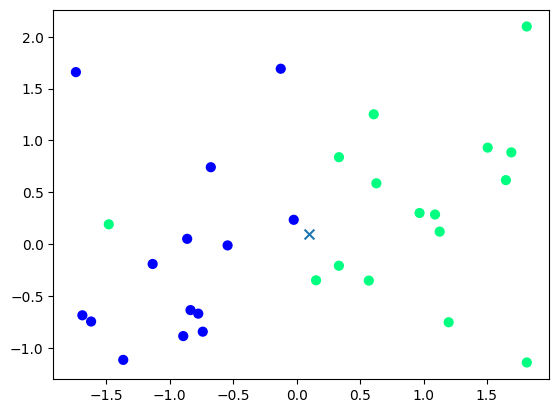

In [7]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn import linear_model
# test test

X, y = make_classification(n_samples = 30,n_features=2, n_redundant=0, n_informative=1, class_sep=1,
                             n_clusters_per_class=1, random_state=1, n_classes=2)

#plt.figure(figsize=(4.5,4));
plt.scatter(X[:, 0], X[:, 1], marker='o', c=y, s=40, cmap='winter');
plt.scatter(0.1,0.1, marker='x', s= 50);


If k = 3, then the object shown with an 'x' will be classified as "green" since the majority class among the set of 3 nearest neighbors of 'x' is "green".

We can also show the decision boundaries (also called Voronoi diagram) for the above example (for k=1 and k=2) as follows:

Text(0.5, 1.0, 'K-NN Classification (k=3)')

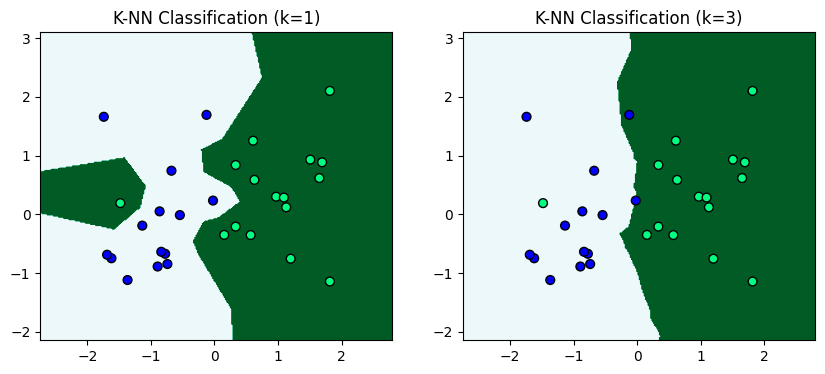

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

from sklearn.datasets import make_classification
fig, ax = plt.subplots(1,2,figsize=(10,4));

clf = KNeighborsClassifier(n_neighbors=1)
# You can play with n_neighbors
clf.fit(X, y)
plot_step = 0.02
n_classes = 2
plot_colors = "rgb"

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = ax[0].contourf(xx, yy, Z, cmap="BuGn")

ax[0].scatter(X[:, 0], X[:, 1], marker='o', c=y, s=40, cmap='winter',edgecolor='black');
ax[0].set_title('K-NN Classification (k=1)')

clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X, y)

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = ax[1].contourf(xx, yy, Z, cmap="BuGn")

ax[1].scatter(X[:, 0], X[:, 1], marker='o', c=y, s=40, cmap='winter',edgecolor='black');
ax[1].set_title('K-NN Classification (k=3)')


### Iris dataset

Load the Iris dataset, a classic dataset in machine learning, from a UCI Machine Learning Repository URL into a pandas DataFrame. The dataset contains information about different iris species, including sepal length, sepal width, petal length, and petal width.

In [5]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
iris = pd.read_csv(url, names=names)
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Preprocess the target variable ('species') by encoding the categorical species names into numerical labels (0, 1, 2) using LabelEncoder. Create a scatter plot of two features (sepal length vs. petal length by default, but you can change x and y to visualize other features) with points colored according to their species, allowing for visual exploration of the data's separability.

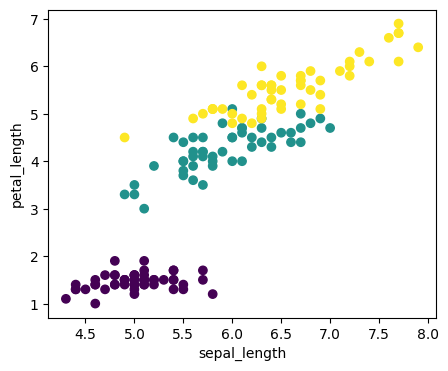

In [8]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])
colors = le.transform(iris.species.values)

x=0;y=2;
# change x and y values to see scatter plots of different features

plt.figure(figsize=(5, 4))
plt.scatter(iris.iloc[:, x], iris.iloc[:, y],c=colors)
#plt.colorbar(ticks=[0, 1, 2])
plt.xlabel(names[x]);
plt.ylabel(names[y]);


Prepare the data for machine learning by separating features (X) from the target variable (y). Split the dataset into training and testing sets using train_test_split. The training set is used to train the model, and the test set is used to evaluate its performance on unseen data. A test_size of 0.1 means 10% of the data is reserved for testing, and random_state ensures reproducibility of the split.

In [9]:
from sklearn.model_selection import train_test_split
X = iris.iloc[:,0:4]
y = le.transform(iris.iloc[:,4]) # Apply LabelEncoder here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=4)

Before model building we perform feature scaling using MinMaxScaler. Scaling is crucial for distance-based algorithms like K-NN, as it prevents features with larger values from dominating the distance calculations. The scaler is fitted only on the training data (X_train) to prevent data leakage, and then both training and testing sets are transformed using this fitted scaler.

In [29]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler = scaler.fit(X_train)
X_train = scaler.transform(X_train)
# test set should be scaled with the scaler trained on the training set.
X_test = scaler.transform(X_test)

We will now initialize and train a K-Nearest Neighbors (K-NN) classifier. After training on the scaled training data, it makes predictions on the scaled test data. The actual and predicted species labels for the test set are then printed to compare them directly.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train);
y_pred = clf.predict(X_test)
print(y_test)
print(y_pred)

[2 0 2 2 2 1 1 0 0 2 0 0 0 1 2]
[2 0 2 2 2 1 2 0 0 2 0 0 0 1 2]


Evaluate the performance of the trained K-NN classifier using a confusion matrix and accuracy score. A confusion matrix visualizes the number of correct and incorrect predictions for each class, providing insight into the model's performance. The accuracy_score provides an overall measure of correct predictions, which is then displayed on a heatmap of the confusion matrix.



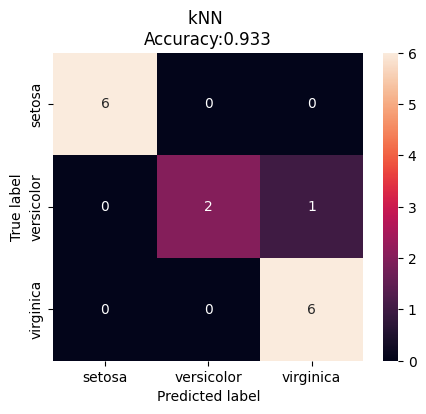

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm,
                     index = ['setosa','versicolor','virginica'],
                     columns = ['setosa','versicolor','virginica'])

plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True)
plt.title('kNN \nAccuracy:{0:.3f}'.format(accuracy_score(y_test, y_pred)))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()



Generate a detailed classification report, which includes precision, recall, F1-score, and support for each class. These metrics offer a more comprehensive understanding of the model's performance beyond just accuracy, especially useful in cases of imbalanced datasets. Precision indicates the accuracy of positive predictions, recall measures the ability to find all positive samples, and F1-score is the harmonic mean of precision and recall.



In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      0.67      0.80         3
           2       0.86      1.00      0.92         6

    accuracy                           0.93        15
   macro avg       0.95      0.89      0.91        15
weighted avg       0.94      0.93      0.93        15



### K-NN Regression

K-NN regression is a non-parametric method used for predicting continuous target variables. Unlike K-NN classification, which assigns a class label based on the majority vote of its nearest neighbors, K-NN regression predicts a value by taking the average (or weighted average) of the target values of its 'k' nearest neighbors.

The following cells demonstrate K-NN regression using a subset of the House Prices dataset.

First, we load the `train.csv` dataset and perform some initial filtering to remove outliers in `GrLivArea` (above-grade living area) and `SalePrice`. We then take a small random sample (2%) of the remaining data to create a smaller dataset for demonstration purposes.

The `GrLivArea` is selected as the feature (X) and `SalePrice` as the target variable (y). The data is then split into training and testing sets. Finally, a scatter plot is generated to visualize the relationship between `GrLivArea` and `SalePrice` in the training data.

In [22]:
# https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques
house = pd.read_csv("train.csv")
# print first 10 houses
house.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


(26, 1) (26,)
(3, 1) (3,)


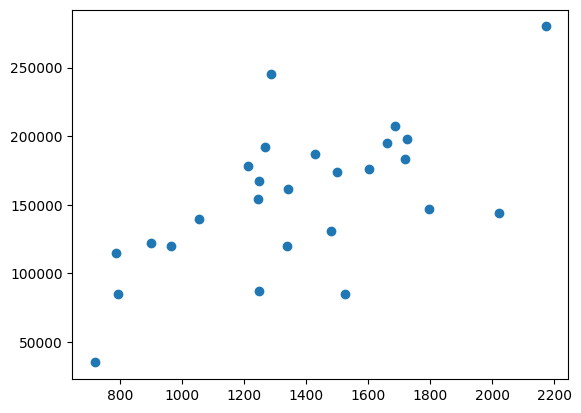

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

house = pd.read_csv("train.csv")
house2 = house[(house.GrLivArea < 4000) & (house.SalePrice < 400000)]
house2 = house2.sample(frac=0.02)
X = house2[['GrLivArea']]
y = house2['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X.values, y, test_size=0.1, random_state=1)
print (X_train.shape, y_train.shape)
print (X_test.shape, y_test.shape)
plt.scatter(X_train, y_train)

The plot below shows the K-Nearest Neighbors (K-NN) regression model's prediction curve (orange line) overlaid on the training data (dark orange points).

**How the K-NN Regression Curve is Formed:**

1.  **Local Averaging:** Unlike linear regression which tries to fit a single straight line globally, K-NN regression makes predictions based on local information. For any given point on the `X_test_line` (the range of GrLivArea values used for prediction), the model looks at its `k` nearest neighbors in the training data.
2.  **Prediction:** The predicted `SalePrice` for that point is then the average of the `SalePrice` values of those `k` neighbors. This process is repeated for many points across the X-axis to form the continuous prediction curve.

**Impact of `n_neighbors` (k value):**

*   **Small `n_neighbors` (e.g., k=1):** If `k` is very small, the model relies on very few neighbors. This often results in a very 'jagged' or 'noisy' regression line that closely follows individual data points, potentially leading to **overfitting**. It captures too much of the random noise in the training data.
*   **Large `n_neighbors` (e.g., k=10+):** As `k` increases, the model averages over more neighbors. This tends to produce a **smoother** regression line, as individual fluctuations are averaged out. However, a `k` that is too large might lead to **underfitting**, where the model is too generalized and fails to capture important patterns in the data.

The optimal `n_neighbors` value is typically found through techniques like cross-validation to balance bias and variance.

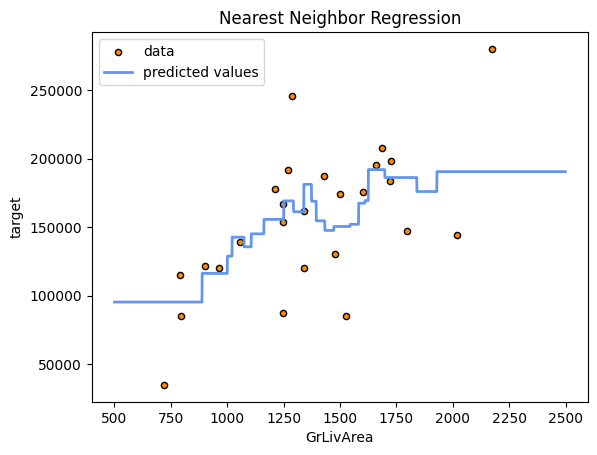

Train MAE: 28671.69230769231


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Fit regression model
regr = KNeighborsRegressor(n_neighbors=5)
#play with n_neighbors
regr.fit(X_train, y_train)

# Predict
X_test_line = np.arange(500, 2500, 1)[:, np.newaxis]
y_pred_line = regr.predict(X_test_line)
y_pred = regr.predict(X_train)

# Plot the results
plt.figure()
plt.scatter(X_train, y_train, s=20, edgecolor="black",
            c="darkorange", label="data")
plt.plot(X_test_line, y_pred_line, color="cornflowerblue",
         label="predicted values", linewidth=2)
plt.xlabel("GrLivArea")
plt.ylabel("target")
plt.title("Nearest Neighbor Regression")
plt.legend()
plt.show()

from sklearn.metrics import mean_absolute_error
print("Train MAE:", mean_absolute_error(y_train, y_pred))


The code block below extends the K-NN regression example to use multiple features, specifically the top 10 attributes most correlated with `SalePrice`. This is a common practice to see how adding more relevant features impacts model performance.

In [ ]:
# Run Regression with top correlated 10 attributes with SalePrice
from sklearn.metrics import mean_squared_log_error
def kaggle_score(y_true,y_pred):
    return np.sqrt(mean_squared_log_error(y_true, y_pred));
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

cors = house.corr(numeric_only=True);
top10 = cors.loc[:, "SalePrice"].sort_values(ascending = False).head(11)
top10 = top10.index.values.tolist()
top10.pop(0)

X = house.loc[:,top10]
y = house.loc[:,'SalePrice']
X = X.astype(float)


mae, kaggle, mape = [], [], []
for i in range(1,10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

    scaler = scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    # test set should be scaled with the scaler trained on the training set.
    X_test = scaler.transform(X_test)


    regr = KNeighborsRegressor(n_neighbors=5)
    model = regr.fit(X_train, y_train)

    test_predictions = model.predict(X_test)
    mae.append(mean_absolute_error(y_test, test_predictions))
    kaggle.append(kaggle_score(y_test, np.abs(test_predictions)))
    mape.append(mean_absolute_percentage_error(y_test, test_predictions))

print("Test MAE:", np.mean(mae))
print("Test Kaggle-Score:", np.mean(kaggle))
print("Test MAPE:", np.mean(mape))

print(top10)


Test MAE: 23167.036834094368
Test Kaggle-Score: 0.18436679887313734
Test MAPE: 13.53965684585275
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


### Curse of Dimensionality

Using more feature might not give better results always.

In [ ]:
X = house.loc[:,'MSSubClass':'SaleCondition']
y = house.loc[:,'SalePrice']
X = pd.get_dummies(X)
mae, kaggle, mape = [], [], []
for i in range(1,10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)
    X_train = X_train.fillna(X_train.mean())
    X_test = X_test.fillna(X_test.mean())

    scaler = scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    # test set should be scaled with the scaler trained on the training set.
    X_test = scaler.transform(X_test)


    regr = KNeighborsRegressor(n_neighbors=5)

    model = regr.fit(X_train, y_train)
    test_predictions = model.predict(X_test)
    mae.append(mean_absolute_error(y_test, test_predictions))
    kaggle.append(kaggle_score(y_test, np.abs(test_predictions)))
    mape.append(mean_absolute_percentage_error(y_test, test_predictions))

print("Test MAE:", np.mean(mae))
print("Test Kaggle-Score:", np.mean(kaggle))
print("Test MAPE:", np.mean(mape))


Test MAE: 26244.938660578387
Test Kaggle-Score: 0.20399451379342165
Test MAPE: 14.827543211381952


It is always good to compare your model's performance with a baseline.

In [ ]:
np.mean(np.abs((y_test- np.mean(y_train))))

np.float64(59167.17706052834)

In order to make sense of the error, let us look at the distribution of sale prices.

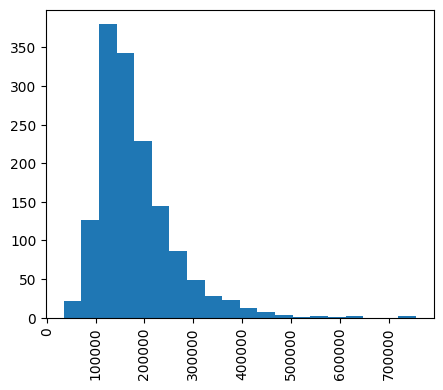

In [ ]:
plt.figure(figsize=(5,4))
plt.xticks(rotation=90)
plt.hist(house.SalePrice, 20);

### Scaling and centering


#### min-max scaling

$$
x_i = \frac{x_i - x_{min}}{x_{max}-x_{min}}
$$

where $x$ is a feature vector (a column of the data matrix), $x_i$ is the original value, $x_{min}$ is the minimum and $x_{max}$ is the maximum value in $x$.

In [ ]:
# create a DataFrame
df = pd.DataFrame([[100, 1990, 100000],
                  [120, 2002, 150000],
                  [90, 2012, 120000]],
                 index = [5, 10,15],
                 columns = ["area","built","price"])
df

,area,built,price
5,100,1990,100000
10,120,2002,150000
15,90,2012,120000


In [ ]:
from sklearn.preprocessing import MinMaxScaler
#Normally, we do not scale the target feature.
df = df.drop(columns=["price"])
scaler = MinMaxScaler()
scaler = scaler.fit(df)
print(scaler.data_max_)
print(scaler.data_min_)

[ 120. 2012.]
[  90. 1990.]


In [ ]:
print(scaler.transform(df))

[[0.33333333 0.        ]
 [1.         0.54545455]
 [0.         1.        ]]


#### Standard scaling

$$
x_i = \frac{x_i - \bar{x}}{s_x}
$$

where $x$ is a feature vector (a column of the data matrix), $x_i$ is the original value, $\bar{x}$ is the mean of $x$ and $s_x$ is the std of $x$.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler = scaler.fit(df)
print(scaler.transform(df))

[[-0.26726124 -1.26012384]
 [ 1.33630621  0.07412493]
 [-1.06904497  1.18599891]]


## Distance metrics

Different distance metrics can be used to define the distance between individual data points. Sklearn's [DistanceMetric](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.DistanceMetric.html#sklearn.metrics.DistanceMetric) class defines various distance metrics.

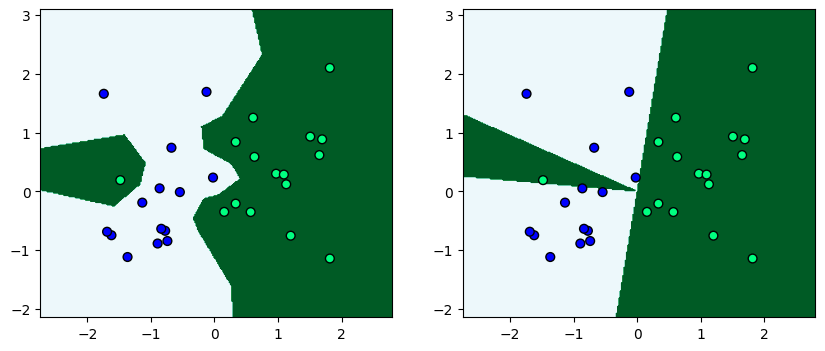

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

from sklearn.datasets import make_classification
fig, ax = plt.subplots(1,2,figsize=(10,4));
X, y = make_classification(n_samples = 30,n_features=2, n_redundant=0, n_informative=1, class_sep=1,
                             n_clusters_per_class=1, random_state=1, n_classes=2)
clf = KNeighborsClassifier(n_neighbors=1)
# You can play with n_neighbors
clf.fit(X, y)
plot_step = 0.02
n_classes = 2
plot_colors = "rgb"

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))


Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = ax[0].contourf(xx, yy, Z, cmap="BuGn")

ax[0].scatter(X[:, 0], X[:, 1], marker='o', c=y, s=40, cmap='winter',edgecolor='black');


clf = KNeighborsClassifier(n_neighbors=1, metric='cosine')
clf.fit(X, y)

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = ax[1].contourf(xx, yy, Z, cmap="BuGn")

ax[1].scatter(X[:, 0], X[:, 1], marker='o', c=y, s=40, cmap='winter',edgecolor='black');


When you use the Euclidean distance (the default in scikit-learn), the K-NN algorithm calculates the straight-line distance between points. The resulting Voronoi diagram consists of polygonal regions where the decision boundaries are perpendicular bisectors between the points. It takes both the direction and the magnitude (position in space) into account.

However, when you change the metric to Cosine distance, the algorithm calculates the angle between the points, treating them as vectors originating from the origin (0,0). Cosine distance completely ignores the magnitude (length) of the vectors and only cares about their direction.

Visually, this changes the Voronoi diagram significantly:

- Instead of enclosed polygonal regions, the decision boundaries for the cosine metric will look like rays or straight lines emanating from the origin.
- Any two points that lie on the same line starting from the origin will have a cosine distance of 0, meaning they are considered "identical" by the algorithm, regardless of how far apart they actually are in the 2D space.
- As a result, the space is divided into angular sectors rather than spatial clusters.

### Cosine Similarity for Document Similarity

Cosine similarity is a powerful metric for determining how similar two documents are, especially when documents are represented as numerical vectors (e.g., using word counts or TF-IDF values). It measures the cosine of the angle between two non-zero vectors. A cosine similarity close to 1 indicates that the documents are very similar, while a value close to 0 suggests dissimilarity.

**Why is it useful for documents?**

1.  **Ignores document length:** Unlike Euclidean distance, cosine similarity is not affected by the length of the documents. If two documents discuss the same topic but one is much longer, their Euclidean distance might be large, but their cosine similarity would still be high because the angle between their word-vector representations would be small.
2.  **Focuses on direction:** It captures the 'direction' or 'topic' of the document. If documents use similar words with similar frequencies, their vectors will point in roughly the same direction, resulting in high cosine similarity.

Documents are typically converted into vectors using methods like Bag-of-Words (word counts) or TF-IDF (Term Frequency-Inverse Document Frequency), where each dimension of the vector corresponds to a unique word in the vocabulary.

### Cosine Similarity and Cosine Distance Formula

**Cosine Similarity** measures the cosine of the angle between two non-zero vectors in a multi-dimensional space. It is calculated using the following formula:

$$ \text{Cosine Similarity}(A, B) = \frac{A \cdot B}{\|A\| \|B\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}} $$

Where:
*   $A$ and $B$ are two vectors (e.g., document vectors).
*   $A \cdot B$ is the dot product of vectors $A$ and $B$.
*   $\|A\|$ is the Euclidean norm (magnitude) of vector $A$.
*   $\|B\|$ is the Euclidean norm (magnitude) of vector $B$.
*   $A_i$ and $B_i$ are the components of vectors $A$ and $B$ respectively.
*   $n$ is the number of dimensions in the vectors.

**Interpretation of Cosine Similarity:**
*   A value of 1 means the vectors are identical in direction (angle of 0 degrees).
*   A value of 0 means the vectors are orthogonal (angle of 90 degrees), indicating no similarity.
*   A value of -1 means the vectors are exactly opposite (angle of 180 degrees).

**Cosine Distance** is simply calculated as 1 minus the cosine similarity. This transforms the similarity score into a distance metric:

$$ \text{Cosine Distance}(A, B) = 1 - \text{Cosine Similarity}(A, B) $$

**Interpretation of Cosine Distance:**
*   A value of 0 means the vectors are identical in direction (maximum similarity, minimum distance).
*   A value of 1 means the vectors are orthogonal (no similarity, moderate distance).
*   A value of 2 means the vectors are exactly opposite (minimum similarity, maximum distance).

Cosine distance is particularly useful when the magnitude of the vectors is not as important as their orientation, such as in document similarity where document length variations are common.

**An example calculation**

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Define two vectors
A = np.array([2, 1, 7])
B = np.array([4, 2, 6])

print(f"Vector A: {A}")
print(f"Vector B: {B}")

# Step 1: Calculate the dot product (A . B)
dot_product = np.dot(A, B)
print(f"\nDot Product (A . B): {dot_product}")

# Step 2: Calculate the magnitude (Euclidean norm) of each vector
magnitude_A = np.linalg.norm(A)
magnitude_B = np.linalg.norm(B)
print(f"Magnitude of A (||A||): {magnitude_A:.2f}")
print(f"Magnitude of B (||B||): {magnitude_B:.2f}")

# Step 3: Calculate Cosine Similarity
cosine_sim = dot_product / (magnitude_A * magnitude_B)
print(f"Cosine Similarity: {cosine_sim:.2f}")

# Step 4: Calculate Cosine Distance
cosine_dist = 1 - cosine_sim
print(f"Cosine Distance: {cosine_dist:.2f}")

# Verification using scikit-learn
# Reshape arrays for sklearn's cosine_similarity function
A_reshaped = A.reshape(1, -1)
B_reshaped = B.reshape(1, -1)

sk_cosine_sim = cosine_similarity(A_reshaped, B_reshaped)[0][0]
print(f"\nScikit-learn Cosine Similarity: {sk_cosine_sim:.2f}")

sk_cosine_dist = 1 - sk_cosine_sim
print(f"Scikit-learn Cosine Distance: {sk_cosine_dist:.2f}")

Vector A: [2 1 7]
Vector B: [4 2 6]

Dot Product (A . B): 52
Magnitude of A (||A||): 7.35
Magnitude of B (||B||): 7.48
Cosine Similarity: 0.95
Cosine Distance: 0.05

Scikit-learn Cosine Similarity: 0.95
Scikit-learn Cosine Distance: 0.05


### Cosine Similarity: Illustrating Word Count Ratios for Document Similarity

Let's consider three hypothetical documents and represent them as word count vectors. We'll use a vocabulary of five words: 'apple', 'orange', 'banana', 'grape', 'strawberry'.

-   **Document 1 (Vector A):** "apple orange banana apple" (2 'apple', 1 'orange', 1 'banana', 0 'grape', 0 'strawberry')
-   **Document 2 (Vector B):** "apple apple orange banana orange apple apple" (4 'apple', 2 'orange', 1 'banana', 0 'grape', 0 'strawberry')
-   **Document 3 (Vector C):** "grape grape strawberry" (0 'apple', 0 'orange', 0 'banana', 2 'grape', 1 'strawberry')

We expect:
-   **High Cosine Similarity between A and B:** They discuss very similar topics, with 'apple' and 'orange' being dominant. Document B is longer but has similar proportions for key words.
-   **Low Cosine Similarity between A and C:** They discuss completely different topics, with no shared words.


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Define vectors for 5 words: 'apple', 'orange', 'banana', 'grape', 'strawberry'

A = np.array([2, 1, 1, 0, 0]) # Document 1: "apple orange banana apple"
B = np.array([4, 2, 1, 0, 0]) # Document 2: "apple apple orange banana orange apple apple"
C = np.array([0, 0, 0, 2, 1]) # Document 3: "grape grape strawberry"

print(f"Vector A: {A}")
print(f"Vector B: {B}")
print(f"Vector C: {C}")

# Calculate Cosine Similarity between A and B
# Reshape for sklearn's cosine_similarity function
A_reshaped = A.reshape(1, -1)
B_reshaped = B.reshape(1, -1)

cosine_sim_AB = cosine_similarity(A_reshaped, B_reshaped)[0][0]
print(f"\nCosine Similarity between A and B: {cosine_sim_AB:.2f}")

# Calculate Cosine Similarity between A and C
C_reshaped = C.reshape(1, -1)
cosine_sim_AC = cosine_similarity(A_reshaped, C_reshaped)[0][0]
print(f"Cosine Similarity between A and C: {cosine_sim_AC:.2f}")

# Calculate Cosine Similarity between B and C
cosine_sim_BC = cosine_similarity(B_reshaped, C_reshaped)[0][0]
print(f"Cosine Similarity between B and C: {cosine_sim_BC:.2f}")


Vector A: [2 1 1 0 0]
Vector B: [4 2 1 0 0]
Vector C: [0 0 0 2 1]

Cosine Similarity between A and B: 0.98
Cosine Similarity between A and C: 0.00
Cosine Similarity between B and C: 0.00


### Interpretation:

-   **Cosine Similarity (A, B) is high (close to 1):** This indicates that Document 1 and Document 2 are very similar in content. Even though Document 2 is longer and has higher absolute word counts, the *proportions* of 'apple' and 'orange' are largely consistent with Document 1, signifying a shared topic.

-   **Cosine Similarity (A, C) is low (0):** This demonstrates that Document 1 and Document 3 have no common words and are thematically distinct. Their vectors are orthogonal, meaning they point in entirely different directions in the vector space, correctly indicating no similarity.

This example illustrates how cosine similarity effectively captures the thematic similarity of documents based on the ratios and distributions of their word counts, regardless of their absolute lengths.

## Flexibility of K-NN

This section section illustrates how K-Nearest Neighbors (K-NN) regression can adapt to complex, non-linear relationships in data, and how its local nature makes it robust to changes or gaps in the dataset, especially when compared to global models like Linear Regression.

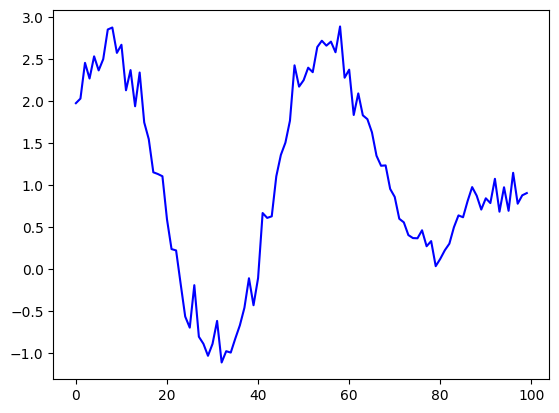

In [ ]:
n = 100
X = np.linspace(0, 5, n)
y = 1 + np.sin(3*X) + np.cos(2*X) + np.random.normal(0, 0.2, n)
plt.plot(y, color="b")

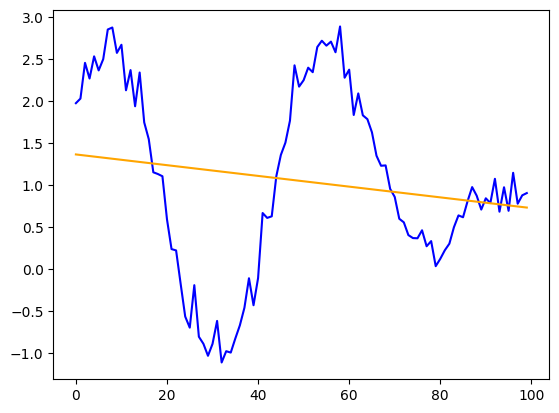

In [ ]:
X = X.reshape(-1,1)
lm = linear_model.LinearRegression().fit(X,y)
preds = lm.predict(X)
plt.plot(y, color="blue")
plt.plot(preds, color="orange")

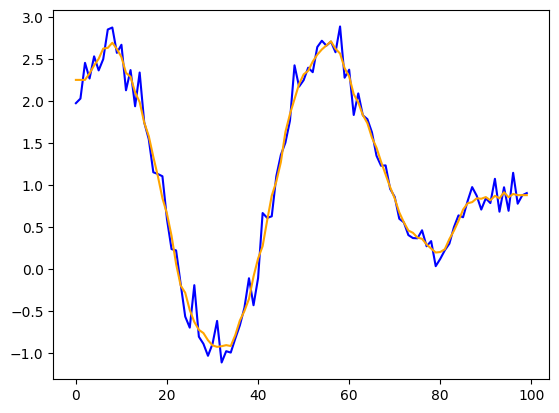

In [ ]:
X = X.reshape(-1,1)
knn = KNeighborsRegressor().fit(X,y)
preds = knn.predict(X)
plt.plot(y, color="blue")
plt.plot(preds, color="orange")

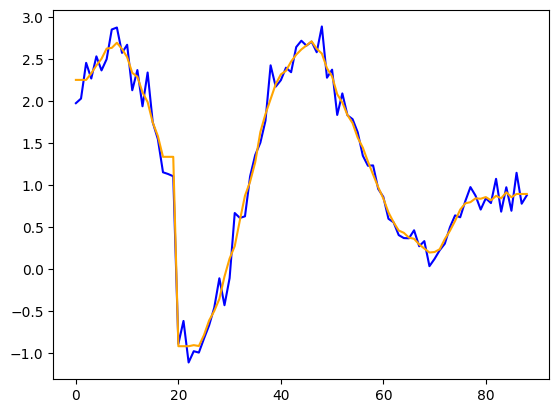

In [ ]:
X = np.vstack((X[0:20], X[30:-1]))
y = np.hstack((y[0:20], y[30:-1]))
knn = KNeighborsRegressor().fit(X,y)
preds = knn.predict(X)
plt.plot(y, color="blue")
plt.plot(preds, color="orange")

## Coding Exercises

### Exercise 1: K-NN Classification with a different `n_neighbors`

Train a K-NN classifier on the Iris dataset using `n_neighbors = 7` and evaluate its accuracy. Compare this to the accuracy obtained with `n_neighbors = 3`.

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
X = iris.iloc[:,0:4]
y = le.transform(iris.iloc[:,4]) # Apply LabelEncoder here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=7)

# Train K-NN with n_neighbors = 7
clf_7 = KNeighborsClassifier(n_neighbors=7)
clf_7.fit(X_train, y_train)
y_pred_7 = clf_7.predict(X_test)

accuracy_7 = accuracy_score(y_test, y_pred_7)
print(f"Accuracy with n_neighbors=7: {accuracy_7:.3f}")

# Compare with n_neighbors=3
clf_3 = KNeighborsClassifier(n_neighbors=3)
clf_3.fit(X_train, y_train)
y_pred_3 = clf_3.predict(X_test)
accuracy_3 = accuracy_score(y_test, y_pred_3)
print(f"Accuracy with n_neighbors=3: {accuracy_3:.3f}")

if accuracy_7 > accuracy_3:
    print("n_neighbors=7 performed better.")
elif accuracy_7 < accuracy_3:
    print("n_neighbors=3 performed better.")
else:
    print("Both n_neighbors values performed equally.")

Accuracy with n_neighbors=7: 0.867
Accuracy with n_neighbors=3: 0.933
n_neighbors=3 performed better.


### Exercise 2: K-NN Classification with a different distance metric

Train a K-NN classifier on the Iris dataset using `n_neighbors = 3` and the `metric='manhattan'` (L1 distance). Evaluate its accuracy and compare it with the default Euclidean distance.

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Train K-NN with Manhattan distance
clf_manhattan = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
clf_manhattan.fit(X_train, y_train)
y_pred_manhattan = clf_manhattan.predict(X_test)

accuracy_manhattan = accuracy_score(y_test, y_pred_manhattan)
print(f"Accuracy with Manhattan distance (n_neighbors=5): {accuracy_manhattan:.3f}")

# For comparison, let's also evaluate Euclidean with n_neighbors=5
clf_euclidean = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
clf_euclidean.fit(X_train, y_train)
y_pred_euclidean = clf_euclidean.predict(X_test)
accuracy_euclidean = accuracy_score(y_test, y_pred_euclidean)
print(f"Accuracy with Euclidean distance (n_neighbors=5): {accuracy_euclidean:.3f}")

if accuracy_manhattan > accuracy_euclidean:
    print("Manhattan distance performed better.")
elif accuracy_manhattan < accuracy_euclidean:
    print("Euclidean distance performed better.")
else:
    print("Both metrics performed equally.")

Accuracy with Manhattan distance (n_neighbors=5): 0.933
Accuracy with Euclidean distance (n_neighbors=5): 0.867
Manhattan distance performed better.


### Exercise 3: K-NN Regression with different `n_neighbors` (Single Feature)

Retrain the K-NN Regressor from the House Prices dataset (using `GrLivArea` as the sole feature) with `n_neighbors = 1`. Calculate the Mean Absolute Error (MAE) on the training data and observe how the regression line changes when plotted.

Train MAE with n_neighbors=1: 0.00


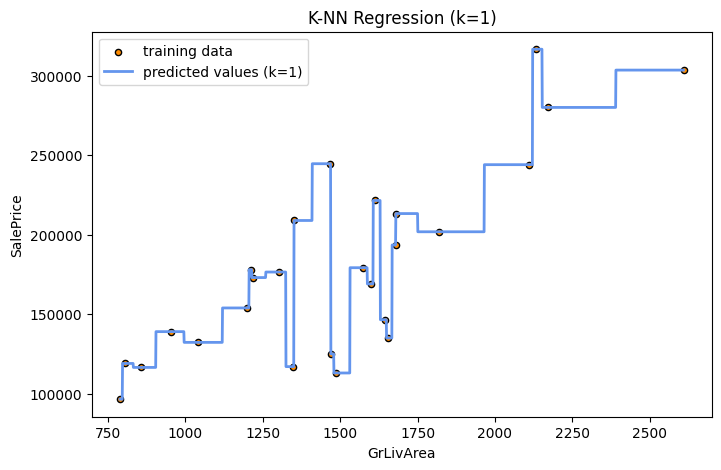

In [23]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

house2 = house[(house.GrLivArea < 4000) & (house.SalePrice < 400000)]
house2 = house2.sample(frac=0.02)
X = house2[['GrLivArea']]
y = house2['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X.values, y, test_size=0.1, random_state=1)

# Fit regression model with n_neighbors = 1
regr_1 = KNeighborsRegressor(n_neighbors=1)
regr_1.fit(X_train, y_train)

# Predict on training data
y_pred_train_1 = regr_1.predict(X_train.reshape(-1, 1)) # Reshape X_train for prediction if it's a 1D array

# Calculate MAE
mae_1 = mean_absolute_error(y_train, y_pred_train_1)
print(f"Train MAE with n_neighbors=1: {mae_1:.2f}")

# Predict for plotting the regression line
X_plot_line = np.arange(X_train.min(), X_train.max(), 1)[:, np.newaxis]
y_pred_plot_line = regr_1.predict(X_plot_line)

# Plot the results
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, s=20, edgecolor="black",
            c="darkorange", label="training data")
plt.plot(X_plot_line, y_pred_plot_line, color="cornflowerblue",
         label="predicted values (k=1)", linewidth=2)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("K-NN Regression (k=1)")
plt.legend()
plt.show()

### Exercise 4: Calculate Cosine Similarity between two custom vectors

Given two vectors, `vec1 = np.array([1, 0, 1, 1, 0])` and `vec2 = np.array([1, 1, 0, 1, 1])`, calculate their cosine similarity and cosine distance. Interpret the result.

In [24]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

vec1 = np.array([1, 0, 1, 1, 0])
vec2 = np.array([1, 1, 0, 1, 1])

print(f"Vector 1: {vec1}")
print(f"Vector 2: {vec2}")

# Reshape for scikit-learn's cosine_similarity function
vec1_reshaped = vec1.reshape(1, -1)
vec2_reshaped = vec2.reshape(1, -1)

cosine_sim = cosine_similarity(vec1_reshaped, vec2_reshaped)[0][0]
cosine_dist = 1 - cosine_sim

print(f"\nCosine Similarity: {cosine_sim:.2f}")
print(f"Cosine Distance: {cosine_dist:.2f}")

if cosine_sim > 0.7:
    print("Interpretation: The vectors are quite similar in direction.")
elif cosine_sim > 0.3:
    print("Interpretation: The vectors have some similarity.")
else:
    print("Interpretation: The vectors are not very similar.")

Vector 1: [1 0 1 1 0]
Vector 2: [1 1 0 1 1]

Cosine Similarity: 0.58
Cosine Distance: 0.42
Interpretation: The vectors have some similarity.


### Exercise 5: Predict a new data point using K-NN Classifier

Using the `clf` (K-NN classifier with `n_neighbors=3`) and `scaler` trained on the Iris dataset, predict the species of a new iris flower with the following measurements: `sepal_length=5.5, sepal_width=2.5, petal_length=4.0, petal_width=1.3`. Remember to scale the new data point before prediction. Also, convert the numerical prediction back to the original species name.

In [31]:
import numpy as np

X = iris.iloc[:,0:4]
y = le.transform(iris.iloc[:,4]) # Apply LabelEncoder here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=7)
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train);

scaler = MinMaxScaler()
scaler = scaler.fit(X_train)

# New data point
new_flower_data = np.array([[5.5, 2.5, 4.0, 1.3]])

# Scale the new data point using the previously fitted scaler
scaled_new_flower_data = scaler.transform(new_flower_data)

# Make a prediction using the trained classifier
predicted_label = clf.predict(scaled_new_flower_data)

# Convert the numerical label back to the species name
predicted_species = le.inverse_transform(predicted_label)

print(f"New flower measurements: {new_flower_data[0]}")
print(f"Predicted species: {predicted_species[0]}")

New flower measurements: [5.5 2.5 4.  1.3]
Predicted species: Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## Conceptual Questions

### Question 1: What is the primary difference between K-NN for classification and K-NN for regression?

**Answer:** The primary difference lies in how the prediction is made based on the 'k' nearest neighbors. For **classification**, K-NN predicts the class label by taking a *majority vote* among its neighbors. For **regression**, K-NN predicts a continuous value by taking the *average (or weighted average)* of the target values of its neighbors.

### Question 2: Explain the concept of the 'curse of dimensionality' in the context of K-NN. How does it affect the performance of the algorithm?

**Answer:** The 'curse of dimensionality' refers to various phenomena that arise when analyzing and organizing data in high-dimensional spaces. In K-NN, as the number of features (dimensions) increases, the distance between data points becomes less meaningful. All points tend to become 'far away' from each other, making it difficult to find truly 'nearest' neighbors. This can lead to K-NN models requiring significantly more data to achieve the same level of statistical significance and predictive power, potentially leading to poorer performance or a requirement for extremely large datasets to be effective.

### Question 3: Why is feature scaling important for K-NN, especially for distance-based metrics like Euclidean distance?

**Answer:** Feature scaling is crucial for K-NN because distance-based algorithms are highly sensitive to the magnitude of features. If features have different scales, features with larger values will dominate the distance calculations, disproportionately influencing the 'nearest neighbor' determination. Scaling ensures that all features contribute equally to the distance computation, preventing features with larger ranges from biasing the model.

### Question 4: When would you prefer using Cosine Similarity over Euclidean Distance as a distance metric in K-NN, and why?

**Answer:** Cosine Similarity is generally preferred over Euclidean Distance when the *magnitude* of the vectors is not as important as their *orientation* or *direction*. This is particularly true in applications like document similarity or recommendation systems, where vectors often represent word counts or item preferences. Cosine similarity effectively ignores the length of the vectors, focusing only on the angle between them, making it robust to variations in document length or overall activity levels of users.

### Question 5: What is the main disadvantage of K-NN in terms of computational complexity and memory usage?

**Answer:** The main disadvantage of K-NN in terms of computational complexity and memory usage is that it is a **lazy learning algorithm**. This means it does not build an explicit model during the training phase. Instead, it memorizes the entire training dataset. For prediction, it has to compute distances between the new data point and *all* training data points. This makes prediction very slow for large datasets (high computational cost) and requires storing the entire dataset in memory (high memory usage).

### Question 6: Calculate Euclidean and Cosine Distances for Word Vectors with Specific Properties

Consider two word vectors, `A = [2, 3, 4]` and `B = [4, 6, 8]`, representing the frequency of certain words in documents.

a) Calculate the Euclidean distance between vectors A and B.

b) Calculate the Cosine Similarity between vectors A and B.

c) From the Cosine Similarity, calculate the Cosine Distance. Interpret what these values tell you about the similarity of the documents, particularly noting the relationship between the Euclidean and Cosine distances.

**Answer:**

a) **Euclidean Distance:**
   $D_E = \sqrt{(2-4)^2 + (3-6)^2 + (4-8)^2}$
   $D_E = \sqrt{(-2)^2 + (-3)^2 + (-4)^2}$
   $D_E = \sqrt{4 + 9 + 16}$
   $D_E = \sqrt{29} \approx 5.385$

b) **Cosine Similarity:**
   $A \cdot B = (2 \times 4) + (3 \times 6) + (4 \times 8) = 8 + 18 + 32 = 58$
   $\|A\| = \sqrt{2^2 + 3^2 + 4^2} = \sqrt{4 + 9 + 16} = \sqrt{29}$
   $\|B\| = \sqrt{4^2 + 6^2 + 8^2} = \sqrt{16 + 36 + 64} = \sqrt{116} = 2\sqrt{29}$
   
   $\text{Cosine Similarity}(A, B) = \frac{A \cdot B}{\|A\| \|B\|} = \frac{58}{\sqrt{29} \times 2\sqrt{29}} = \frac{58}{2 \times 29} = \frac{58}{58} = 1$

c) **Cosine Distance:**
   $\text{Cosine Distance}(A, B) = 1 - \text{Cosine Similarity}(A, B) = 1 - 1 = 0$

**Interpretation:**
- The Euclidean distance is approximately 5.385, indicating a notable spatial distance between the two points.
- The Cosine Similarity is 1, which means the vectors are perfectly collinear; they point in exactly the same direction. This indicates maximum possible similarity in terms of orientation.
- The Cosine Distance is 0, reinforcing the perfect directional similarity. A Cosine Distance of 0 means the vectors are considered identical in orientation, regardless of their magnitude.

This scenario often arises when documents are identical in content/topic (same word ratios) but one is simply longer (has higher absolute word counts), causing a larger Euclidean distance but perfect cosine similarity.

### Question 7: Precision and Recall Calculation

Consider a binary classification model that predicted whether an email is spam. After evaluating the model on a test set, the following results were obtained:

*   **True Positives (TP):** 90 (correctly identified spam emails)
*   **False Positives (FP):** 10 (non-spam emails incorrectly identified as spam)
*   **True Negatives (TN):** 850 (correctly identified non-spam emails)
*   **False Negatives (FN):** 50 (spam emails incorrectly identified as non-spam)

Calculate the Precision and Recall for this model.

**Answer:**

a) **Precision:**
   Precision measures the proportion of positive identifications that were actually correct. It answers the question: "Of all emails predicted as spam, how many actually were spam?"
   
   $\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$
   $\text{Precision} = \frac{90}{90 + 10} = \frac{90}{100} = 0.90$

b) **Recall (Sensitivity):**
   Recall measures the proportion of actual positives that were correctly identified. It answers the question: "Of all actual spam emails, how many were correctly identified?"
   
   $\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$
   $\text{Recall} = \frac{90}{90 + 50} = \frac{90}{140} \approx 0.643$

**Interpretation:**
- The model has a precision of 90%, meaning that when it predicts an email is spam, it is correct 90% of the time.
- The model has a recall of approximately 64.3%, meaning it correctly identifies about 64.3% of all actual spam emails.

### Question 8: K-NN Classification Prediction with Multiple Classes

In a multi-class classification problem with three classes (Class A, Class B, Class C), a K-NN classifier with `k=7` is used. A new data point's seven nearest neighbors belong to the following classes:

*   Class A
*   Class B
*   Class A
*   Class C
*   Class A
*   Class B
*   Class A

What will be the predicted class for the new data point?

**Answer:**

For K-NN classification, the predicted class is determined by a majority vote among its 'k' nearest neighbors.

Neighbors' classes: [Class A, Class B, Class A, Class C, Class A, Class B, Class A]

Let's count the occurrences of each class:
*   Count of Class A: 4
*   Count of Class B: 2
*   Count of Class C: 1

Since 'Class A' has the most votes (4 out of 7), the predicted class for the new data point will be **Class A**.

### Question 9: K-NN Regression Prediction with Weighted Average

In a K-NN regression model with `k=3`, a new data point needs a prediction. Its three nearest neighbors have target values and distances as follows:

1.  Neighbor 1: Target Value = 100, Distance = 1.0
2.  Neighbor 2: Target Value = 120, Distance = 2.0
3.  Neighbor 3: Target Value = 90, Distance = 3.0

If the prediction is made using a weighted average where weights are inversely proportional to the distance (i.e., weight = 1/distance), what would be the predicted value for the new data point?

**Answer:**

For K-NN regression with a weighted average (inverse of distance as weight):

1.  **Calculate Weights:**
    *   Weight for Neighbor 1 (W1) = 1 / 1.0 = 1.0
    *   Weight for Neighbor 2 (W2) = 1 / 2.0 = 0.5
    *   Weight for Neighbor 3 (W3) = 1 / 3.0 = 0.333

2.  **Calculate Weighted Sum of Target Values:**
    *   Weighted Sum = (100 * 1.0) + (120 * 0.5) + (90 * 0.333)
    *   Weighted Sum = 100 + 60 + 29.97
    *   Weighted Sum = 189.97

3.  **Calculate Sum of Weights:**
    *   Sum of Weights = 1.0 + 0.5 + 0.333
    *   Sum of Weights = 1.833

4.  **Calculate Predicted Value:**
    *   Predicted Value = Weighted Sum / Sum of Weights
    *   Predicted Value = 189.97 / 1.833
    *   Predicted Value \approx 103.63

The predicted value for the new data point would be approximately **103.63**.